<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/Project_4/ML_AI_Projects_4_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Task 3**

**Task 3: Part 1**

In [ ]:
# BERT Embeddings
import torch
from transformers import BertTokenizer, BertModel

# Load embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

def get_bert_embedding(word):
    inputs = tokenizer(word, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
    # Output is average of last hidden states
    return outputs.last_hidden_state.mean(dim=1).numpy()

def user_input():
    # Capture user inputs and embedds them
    word1 = input("Enter the first word: ")
    word2 = input("Enter the second word: ")

    emb1 = get_bert_embedding(word1)
    emb2 = get_bert_embedding(word2)

    print(f"\nEmbedding for '{word1}' shape: {emb1.shape}")
    print(f"Embedding for '{word2}' shape: {emb2.shape}")
    return word1, emb1, word2, emb2

In [ ]:
w1, e1, w2, e2 = user_input()

Enter the first word: cat
Enter the second word: dog

Embedding for 'cat' shape: (1, 768)
Embedding for 'dog' shape: (1, 768)


I chose BERT embeddings over the others due to it having contextual embeddings and personal interest in the BERT model. BERT will generate a different embedding for the same word if the surrounding context is different. BERT automatically handles OOV, it breaks words down into known subparts, so any english language word will be in vocab.

**Task 3: Part 2**

Batch Similarity Results:
chair vs desk: 0.8511
cat vs dog: 0.9009
apple vs banana: 0.9216

PCA visualization:


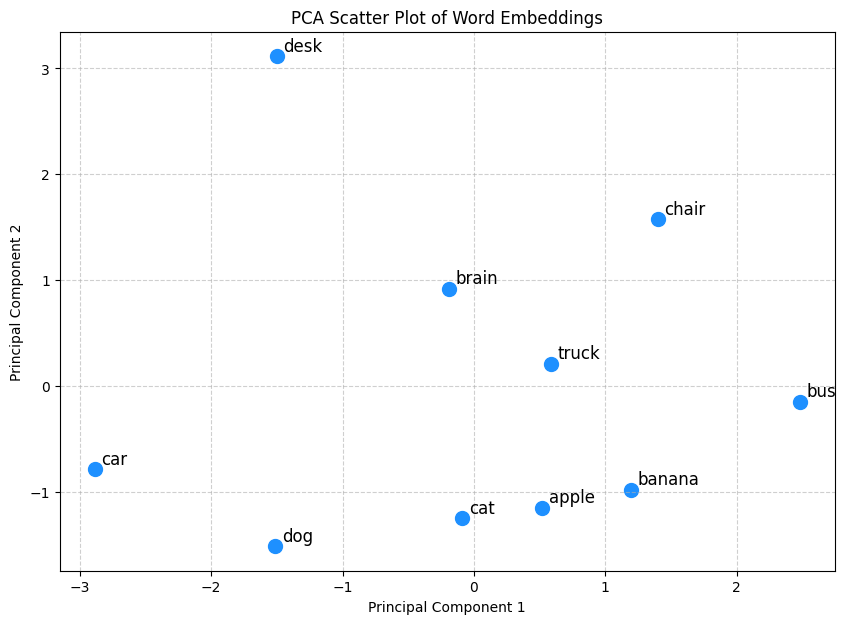

In [ ]:
# Cosine Similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

def batch_similarity(word_pairs):
    # Calls cosine similarity for batches
    results = {}
    for w1, w2 in word_pairs:
        e1 = get_bert_embedding(w1)
        e2 = get_bert_embedding(w2)
        results[f"{w1} vs {w2}"] = cosine_similarity(e1, e2)[0][0]
    return results

# Batch Processing
test_pairs = [("chair", "desk"), ("cat", "dog"), ("apple", "banana")]
print("Batch Similarity Results:")
for pair, score in batch_similarity(test_pairs).items():
    print(f"{pair}: {score:.4f}")

# PCA Visualization
words_to_plot = ["cat", "dog", "desk", "chair", "car", "truck", "bus", "apple", "banana", "brain"]
print(f"\nPCA visualization:")
embeddings = np.vstack([get_bert_embedding(w) for w in words_to_plot])

# Reduce dimensionality for PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], color='dodgerblue', s=100)

for i, word in enumerate(words_to_plot):
    plt.annotate(word, (reduced_embeddings[i, 0] + 0.05, reduced_embeddings[i, 1] + 0.05), fontsize=12)

plt.title("PCA Scatter Plot of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Cosine similarity is useful because it helps understand the difference or similarity in meaning of embeddings. In the vector space, the direction of the vector represents meaning, and cosine similarity measures the similarity of direction, helping us quantify similarity and difference in meaning.

**Task 3: Part 3**

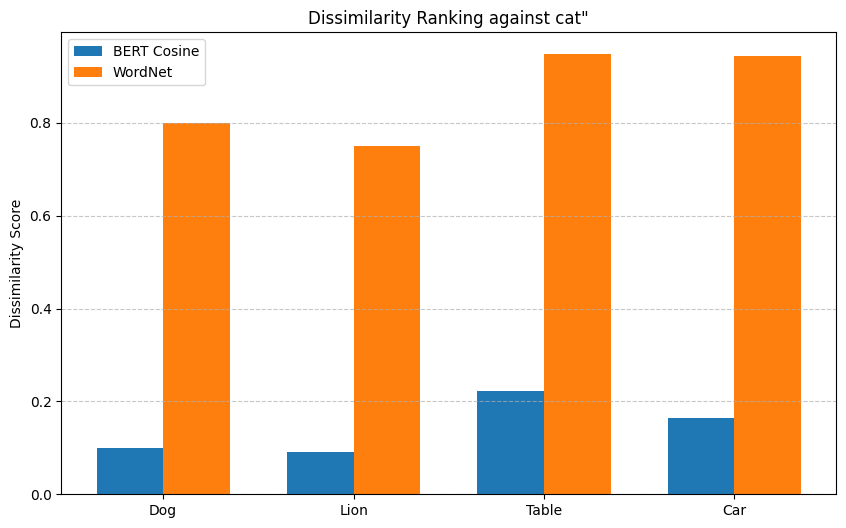

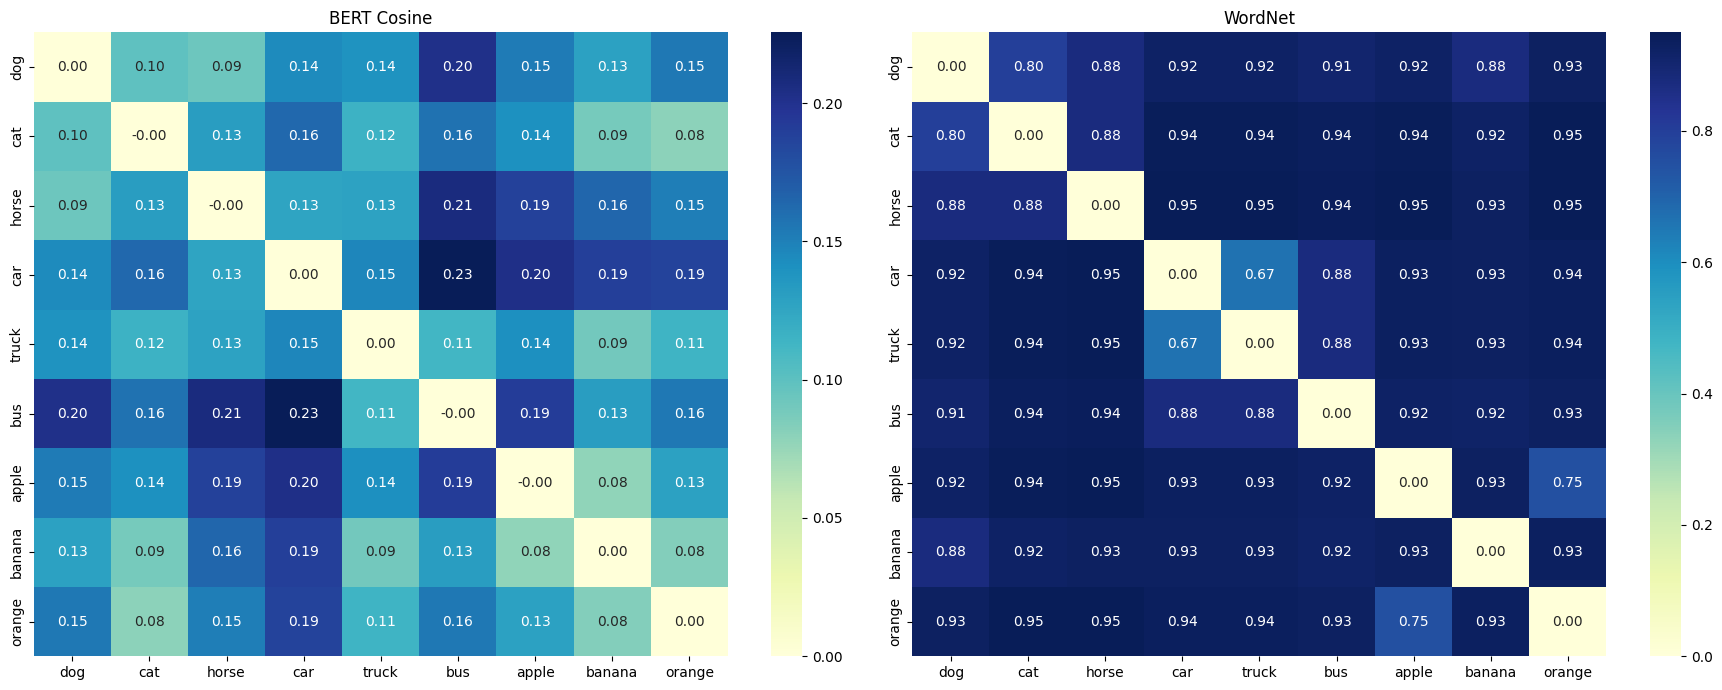

In [ ]:
# Dissimilarity Metric
import nltk
import seaborn as sns
from nltk.corpus import wordnet as wn

# Download wordnet
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

def calculate_dissimilarity(word1, word2, metric='cosine'):
    # Calculates dissimilarity
    if metric == 'cosine':
        emb1 = get_bert_embedding(word1)
        emb2 = get_bert_embedding(word2)
        return 1.0 - cosine_similarity(emb1, emb2)[0][0]

    elif metric == 'wordnet':
        # Use WordNet dissimilarity
        synsets1 = wn.synsets(word1)
        synsets2 = wn.synsets(word2)

        if not synsets1 or not synsets2:
            return 1.0 # Max dissimilarity if OOV

        path_sim = synsets1[0].path_similarity(synsets2[0])
        if path_sim is None:
            return 1.0
        return 1.0 - path_sim

# Compare cat dissimilarity to other words
target_word = "cat"
comparison_words = ["dog", "lion", "table", "car"]

cosine_scores = [calculate_dissimilarity(target_word, w, metric='cosine') for w in comparison_words]
wordnet_scores = [calculate_dissimilarity(target_word, w, metric='wordnet') for w in comparison_words]

x = np.arange(len(comparison_words))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, cosine_scores, width, label='BERT Cosine')
ax.bar(x + width/2, wordnet_scores, width, label='WordNet')

ax.set_ylabel('Dissimilarity Score')
ax.set_title(f'Dissimilarity Ranking against cat"')
ax.set_xticks(x)
ax.set_xticklabels([w.capitalize() for w in comparison_words])
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Similarity heatmap
category_words = ["dog", "cat", "horse", "car", "truck", "bus", "apple", "banana", "orange"]
n = len(category_words)

matrix_cosine = np.zeros((n, n))
matrix_wordnet = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matrix_cosine[i, j] = calculate_dissimilarity(category_words[i], category_words[j], metric='cosine')
        matrix_wordnet[i, j] = calculate_dissimilarity(category_words[i], category_words[j], metric='wordnet')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(matrix_cosine, xticklabels=category_words, yticklabels=category_words,
            ax=axes[0], cmap="YlGnBu", annot=True, fmt=".2f")
axes[0].set_title("BERT Cosine")

sns.heatmap(matrix_wordnet, xticklabels=category_words, yticklabels=category_words,
            ax=axes[1], cmap="YlGnBu", annot=True, fmt=".2f")
axes[1].set_title("WordNet")

plt.tight_layout()
plt.show()

Custom dissimilarity score: Semantic contrast measure using WordNet

Citation: WordNet paper. https://dl.acm.org/doi/pdf/10.1145/219717.219748

This captures disimilarity better than cosine similarity alone because it helps to prevent context from interferring with our similarity. This method prevents words that appear in similar contexts from being grouped together, since WordNet attempts to measure the difference in what the words actually mean, instead of measuring the difference in how often they share surrounding words in a sentence.